# Regressão Linear Simples — Exemplo 01

Prever o **valor total da nota fiscal** com base na **quantidade total de itens vendidos**.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 1. Conexão com o Banco de Dados PostgreSQL

In [2]:
usuario = "datadt_data_analytics"
senha = "DataAnalytics$100"
host = "postgresql-datadt.alwaysdata.net"
porta = "5432"
banco = "datadt_digital_corporativo"

engine = create_engine(
    f"postgresql+psycopg2://{usuario}:{senha}@{host}:{porta}/{banco}"
)

## 2. Consulta SQL

Cada linha representa uma nota fiscal. `X` = quantidade total de itens, `Y` = valor total da nota.

In [3]:
sql = """
SELECT 
    nf.id AS id_nota_fiscal,
    SUM(inf.quantidade) AS quantidade_total_itens,
    SUM(inf.quantidade * inf.valor_unitario) AS valor_total_nota
FROM vendas.nota_fiscal nf
JOIN vendas.item_nota_fiscal inf 
    ON inf.id_nota_fiscal = nf.id
GROUP BY nf.id
ORDER BY nf.id;
"""

## 3. Carregando os Dados

In [4]:
df = pd.read_sql(sql, engine)

print("Primeiras linhas da base:")
print(df.head())

print("\nInformações da base:")
print(df.info())

print("\nResumo estatístico:")
print(df.describe())

Primeiras linhas da base:
   id_nota_fiscal  quantidade_total_itens  valor_total_nota
0               1                       4             120.0
1               2                       1              43.0
2               3                       4            3560.0
3               4                       6            8080.0
4               5                       1             139.0

Informações da base:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128889 entries, 0 to 128888
Data columns (total 3 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id_nota_fiscal          128889 non-null  int64  
 1   quantidade_total_itens  128889 non-null  int64  
 2   valor_total_nota        128889 non-null  float64
dtypes: float64(1), int64(2)
memory usage: 3.0 MB
None

Resumo estatístico:
       id_nota_fiscal  quantidade_total_itens  valor_total_nota
count   128889.000000           128889.000000     128889.000000
mean    

## 4. Tratamento Básico dos Dados

In [5]:
df = df.dropna()

df = df[
    (df["quantidade_total_itens"] > 0) &
    (df["valor_total_nota"] > 0)
]

print("Quantidade de registros após tratamento:")
print(len(df))

Quantidade de registros após tratamento:
128889


## 5. Definindo X e Y

`X` precisa estar em formato de matriz (dois colchetes). `Y` é a variável alvo.

In [6]:
X = df[["quantidade_total_itens"]]
y = df["valor_total_nota"]

## 6. Divisão em Treino e Teste

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## 7. Treinando o Modelo

In [8]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 8. Coeficientes do Modelo

In [9]:
intercepto = modelo.intercept_
coeficiente = modelo.coef_[0]

print("Modelo treinado:")
print(f"Intercepto: {intercepto:.2f}")
print(f"Coeficiente: {coeficiente:.2f}")

print("\nEquação da regressão:")
print(f"valor_total_nota = {intercepto:.2f} + {coeficiente:.2f} * quantidade_total_itens")

Modelo treinado:
Intercepto: -3.64
Coeficiente: 977.07

Equação da regressão:
valor_total_nota = -3.64 + 977.07 * quantidade_total_itens


## 9. Fazendo Previsões

In [10]:
y_pred = modelo.predict(X_test)

resultado = pd.DataFrame({
    "quantidade_total_itens": X_test["quantidade_total_itens"],
    "valor_real": y_test,
    "valor_previsto": y_pred
})

print("Comparação entre valor real e valor previsto:")
print(resultado.head())

Comparação entre valor real e valor previsto:
        quantidade_total_itens  valor_real  valor_previsto
6818                         3     7500.00     2927.570172
76628                        7     1838.39     6835.852649
26139                       12    14525.91    11721.205745
3896                         1     2800.00      973.428934
121814                       4      545.04     3904.640791


## 10. Avaliação do Modelo

In [11]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Métricas de avaliação:")
print(f"MAE  - Erro médio absoluto: {mae:.2f}")
print(f"MSE  - Erro quadrático médio: {mse:.2f}")
print(f"R²   - Coeficiente de determinação: {r2:.4f}")

Métricas de avaliação:
MAE  - Erro médio absoluto: 3828.16
MSE  - Erro quadrático médio: 26694650.86
R²   - Coeficiente de determinação: 0.3786


## 11. Visualização dos Dados e da Reta de Regressão

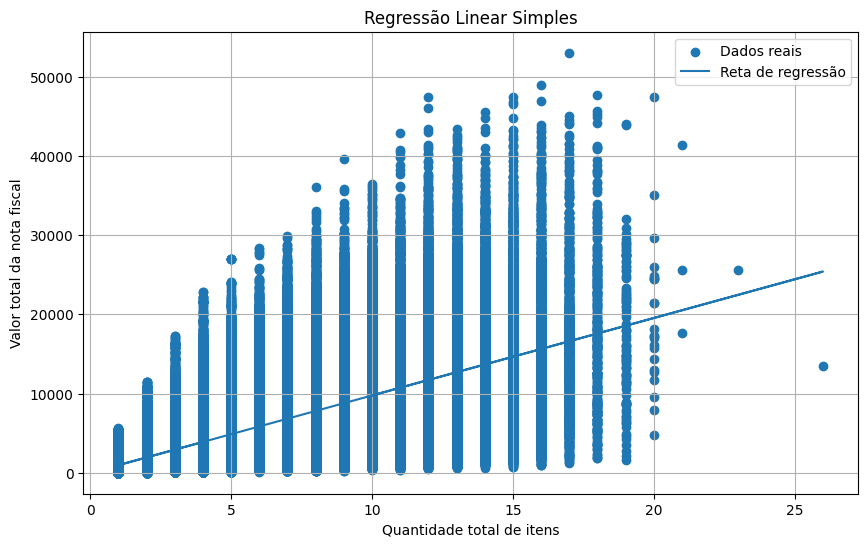


Gráfico salvo em: grafico_regressao_exemplo01.png


In [12]:
plt.figure(figsize=(10, 6))

plt.scatter(X, y, label="Dados reais")
plt.plot(X, modelo.predict(X), label="Reta de regressão")

plt.title("Regressão Linear Simples")
plt.xlabel("Quantidade total de itens")
plt.ylabel("Valor total da nota fiscal")
plt.legend()
plt.grid(True)

arquivo_grafico = "grafico_regressao_exemplo01.png"
plt.savefig(arquivo_grafico, dpi=300, bbox_inches="tight")
plt.show()

print(f"\nGráfico salvo em: {arquivo_grafico}")

## 12. Simulação de Previsão

Prever o valor de uma nota com 10 itens vendidos.

In [13]:
nova_quantidade = pd.DataFrame({
    "quantidade_total_itens": [10]
})

valor_estimado = modelo.predict(nova_quantidade)

print("Simulação:")
print(f"Para uma nota com 10 itens, o valor estimado é R$ {valor_estimado[0]:.2f}")

Simulação:
Para uma nota com 10 itens, o valor estimado é R$ 9767.06
